## Holiday Package Prediciton

### 1) Problem statement.
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.
### 2) Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data Cleaning
### Handling Missing values
1. Handling Missing values
2. Handling Duplicates
3. Check data type
4. Understand the dataset

In [3]:
df.isnull().sum(axis=0)

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [4]:
# Check all categories
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [5]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [6]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [7]:
df['Age'].unique()

array([41., 49., 37., 33., nan, 32., 59., 30., 38., 36., 35., 31., 34.,
       28., 29., 22., 53., 21., 42., 44., 46., 39., 24., 43., 50., 27.,
       26., 48., 55., 45., 56., 23., 51., 40., 54., 58., 20., 25., 19.,
       57., 52., 47., 18., 60., 61.])

In [8]:
df['CityTier'].value_counts()

CityTier
1    3190
3    1500
2     198
Name: count, dtype: int64

In [9]:
df['MonthlyIncome'].unique()

array([20993., 20130., 17090., ..., 22097., 22995., 21471.])

In [10]:
df['ProdTaken'].unique()

array([1, 0])

In [11]:
df['DurationOfPitch'].unique()

array([  6.,  14.,   8.,   9.,  30.,  29.,  33.,  22.,  21.,  32.,  25.,
        27.,  11.,  17.,  15.,  13.,  12.,  16.,  10.,  31.,  18.,  nan,
        24.,  35.,  28.,  20.,  26.,  34.,  23.,   5.,  19., 126.,   7.,
        36., 127.])

In [12]:
df['Occupation'].unique()

array(['Salaried', 'Free Lancer', 'Small Business', 'Large Business'],
      dtype=object)

In [13]:
df['NumberOfChildrenVisiting'].unique()

array([ 0.,  2.,  1., nan,  3.])

In [14]:
df['NumberOfPersonVisiting'].unique()

array([3, 2, 1, 4, 5])

In [15]:
df['NumberOfFollowups'].unique()

array([ 3.,  4.,  2.,  5., nan,  1.,  6.])

In [16]:
df['NumberOfTrips'].unique()

array([ 1.,  2.,  7.,  5.,  6.,  3.,  4., 19., 21.,  8., nan, 20., 22.])

In [17]:
df['OwnCar'].unique()

array([1, 0])

In [18]:
df['Designation'].value_counts()

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64

In [19]:
df['PitchSatisfactionScore'].unique()

array([2, 3, 5, 4, 1])

In [20]:
df['Passport'].unique()

array([1, 0])

In [21]:
df['PreferredPropertyStar'].unique()

array([ 3.,  4.,  5., nan])

In [22]:
df['ProductPitched'].unique()

array(['Deluxe', 'Basic', 'Standard', 'Super Deluxe', 'King'],
      dtype=object)

In [23]:
df['ProdTaken'].unique()

array([1, 0])

In [24]:
df['NumberOfFollowups'].unique()

array([ 3.,  4.,  2.,  5., nan,  1.,  6.])

In [25]:
df['CustomerID'].unique()

array([200000, 200001, 200002, ..., 204885, 204886, 204887])

In [26]:
df['Gender'] = df['Gender'].replace('Fe Male','Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single','Unmarried')

In [27]:
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [28]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [29]:
df.head(5)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [30]:
# Check Missing values-: 
# these are the features with nan value-:
features_with_na = [features for features in df.columns if df[features].isnull().sum() >= 1]
# names of features with NULL values in its column-:
print(features_with_na)
# It returns the percentage of missing (NULL/NaN) values in the Age column.
for feature in features_with_na:
    print(f"{feature }-: {round(df[feature].isnull().mean()*100,5)}% missing values")

['Age', 'TypeofContact', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'NumberOfChildrenVisiting', 'MonthlyIncome']
Age-: 4.62357% missing values
TypeofContact-: 0.51146% missing values
DurationOfPitch-: 5.13502% missing values
NumberOfFollowups-: 0.92062% missing values
PreferredPropertyStar-: 0.53191% missing values
NumberOfTrips-: 2.86416% missing values
NumberOfChildrenVisiting-: 1.35025% missing values
MonthlyIncome-: 4.76678% missing values


In [31]:
round(5340.203345,5)

5340.20334

In [32]:
round(5340.2045,5)

5340.2045

In [33]:
df['Age'].isnull().sum()

np.int64(226)

In [34]:
# It returns the percentage of missing (NULL/NaN) values in the Age column.
# So; it will do sum of all rows which has Nan values for that column same as .sum() method then divdie by the TOTAL NUMBER of rows in that column which will give mean but it actually the percentage of NULL/NaN values in that column.
df['Age'].isnull().mean()

np.float64(0.046235679214402615)

In [35]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [36]:
features_with_na

['Age',
 'TypeofContact',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [38]:
# statistics on numerical columns (Null cols)-:

# select_dtypes() means:
# Select columns based on their data type.

# Simple meaning:
# It filters columns by type of data.
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


If difference in mean and 50th percentile is  MORE then there are MANY OUTLIERS

If difference in mean and 50th percentile is  LESS then there are LESS or NO OUTLIERS

## Imputing Null values
1. Impute Median value for Age column
2. Impute Mode for Type of Contract
3. Impute Median for Duration of Pitch
4. Impute Mode for NumberofFollowup as it is Discrete feature cause it has only 6 different values/classes/categories-: 1,2,3,4,5,6
5. Impute Mode for PreferredPropertyStar
6. Impute Median for NumberofTrips
7. Impute Mode for NumberOfChildrenVisiting
8. Impute Median for MonthlyIncome

In [39]:
features_with_na

['Age',
 'TypeofContact',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [40]:
# For numerical features => median replacement
# For categorical features => mode replacement

# median() and mode() is caluclated by removing/ignoring the NaN values
# Missing values are not used in the calculation and also not considered/counted while calculation of mean() and median()
for i in features_with_na:
    if df[i].dtype == 'O':
        # We are writing mode()[0] cause mode() returns a list and if there are 2 mode values in the list then we need to write [0] in order to replace Nan with the mode value else the NaN column will not be replced by a list as we are passing a variabble[LIST of mode] without any INDEXING
        df.fillna({i:df[i].mode()[0]},inplace=True)
    else:
        df.fillna({i:df[i].median()},inplace=True)

In [41]:
df['TypeofContact'].dtype

dtype('O')

In [42]:
'O'==df['TypeofContact'].dtype

True

In [43]:
df.fillna({'TypeofContact':df['TypeofContact'].mode()},inplace=True)

In [44]:
df.isna().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [45]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [46]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [47]:
# CustomerID not important feature in dataset for PREDICTION
# So; lets DROP IT-:
df.drop("CustomerID",inplace=True,axis=1)

In [48]:
df

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Unmarried,3.0,1,3,1,2.0,Executive,21212.0
4885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Unmarried,3.0,0,5,0,2.0,Executive,20289.0


## Feature Engineering

### Feature Extraction

In [49]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [50]:
df['TotalVisiting'] = df['NumberOfChildrenVisiting'] + df['NumberOfPersonVisiting']
df.drop(columns=['NumberOfChildrenVisiting','NumberOfPersonVisiting'],inplace=True,axis=1)

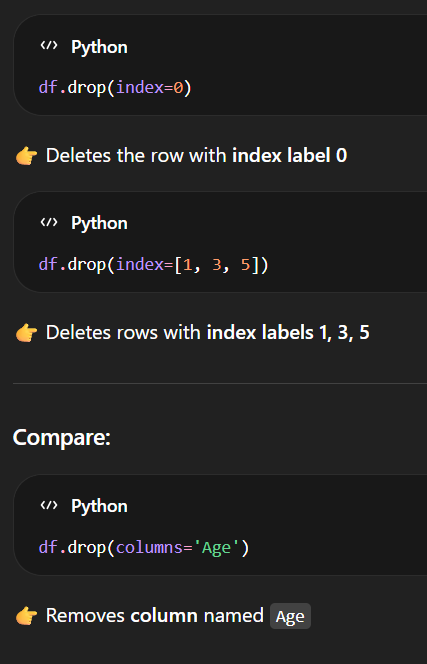

In [51]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [52]:
# get all numeric features-:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print(f"Num of numeric features -: {len(num_features)}")

Num of numeric features -: 12


In [53]:
# get all categorical features-:
category_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print(f"Num of categorical features -: {len(category_features)}")

Num of categorical features -: 6


In [54]:
# Discrete features-:
discrete_features = [feature for feature in num_features if len(df[feature].unique()) <= 25]
print('Num of Discrete Features: ',len(discrete_features))

Num of Discrete Features:  9


In [55]:
discrete_features

['ProdTaken',
 'CityTier',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'TotalVisiting']

In [56]:
# Continuous features-:
continuous_features = [feature for feature in num_features if feature not in discrete_features]
print('Num of continuous features: ',len(continuous_features))

Num of continuous features:  3


In [57]:
continuous_features

['Age', 'DurationOfPitch', 'MonthlyIncome']

In [58]:
# Train test split and model training-:

In [59]:
from sklearn.model_selection import train_test_split
# DEPENDENT and INDEPENDENT FEATURES-:
X = df.drop(['ProdTaken'],axis=1)
y = df['ProdTaken']

In [60]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [61]:
X

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,49.0,Self Enquiry,3,9.0,Small Business,Male,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,Manager,26576.0,4.0
4884,28.0,Company Invited,1,31.0,Salaried,Male,5.0,Basic,3.0,Unmarried,3.0,1,3,1,Executive,21212.0,6.0
4885,52.0,Self Enquiry,3,17.0,Salaried,Female,4.0,Standard,4.0,Married,7.0,0,1,1,Senior Manager,31820.0,7.0
4886,19.0,Self Enquiry,3,16.0,Small Business,Male,4.0,Basic,3.0,Unmarried,3.0,0,5,0,Executive,20289.0,5.0


In [62]:
y

0       1
1       0
2       1
3       0
4       0
       ..
4883    1
4884    1
4885    1
4886    1
4887    1
Name: ProdTaken, Length: 4888, dtype: int64

In [63]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [64]:
# seperate dataset into train and test-:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [65]:
X_train.shape, X_test.shape

((3666, 17), (1222, 17))

In [66]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   object 
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   object 
 5   Gender                  4888 non-null   object 
 6   NumberOfFollowups       4888 non-null   float64
 7   ProductPitched          4888 non-null   object 
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   object 
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   

In [67]:
# Create a column transformer with 3 types of transformers-:
cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

In [68]:
cat_features

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')

In [69]:
num_features

Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object')

In [70]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
# Column Transformer does column transformation in 1 PIPELINE according to the column transformation MODELS passed to it.

numeric_transformer = StandardScaler()
# its always prefereable to do drop='first' in OHE
# drop='first' will DROP the category which comes FIRST -: ALPHABETICALLY WISE
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    # always pass list of tuples in ColumnTransformer and name of that transformation in tuple can be ARBITRARY
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScaler",numeric_transformer,num_features)
    ]
)

In [71]:
X_train = preprocessor.fit_transform(X_train)

In [72]:
X_test = preprocessor.transform(X_test)

In [73]:
X_train

array([[ 1.        ,  1.        ,  0.        , ..., -1.27370232,
        -0.41594151, -0.05880979],
       [ 0.        ,  0.        ,  1.        , ...,  0.7851128 ,
        -0.22414633, -0.76800938],
       [ 1.        ,  0.        ,  0.        , ...,  0.7851128 ,
        -0.71121511, -0.76800938],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.7851128 ,
        -0.3560529 ,  0.65038981],
       [ 1.        ,  0.        ,  0.        , ...,  0.7851128 ,
        -0.24859453,  0.65038981],
       [ 0.        ,  0.        ,  1.        , ..., -1.27370232,
        -1.07585337, -1.47720898]])

In [74]:
X_test

array([[ 0.        ,  0.        ,  0.        , ..., -1.27370232,
        -0.73187289, -0.76800938],
       [ 1.        ,  0.        ,  0.        , ..., -1.27370232,
        -0.664972  , -0.05880979],
       [ 1.        ,  0.        ,  0.        , ...,  0.7851128 ,
        -0.41613103, -0.76800938],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.7851128 ,
        -0.22414633, -0.76800938],
       [ 1.        ,  0.        ,  0.        , ...,  0.7851128 ,
        -0.53515017,  1.35958941],
       [ 1.        ,  0.        ,  0.        , ...,  0.7851128 ,
        -1.1984734 , -0.76800938]])

In [75]:
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(drop='first'),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')),
                                ('StandardScaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object'))])

In [76]:
# Adaboost classifer training-:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Efficient & Correct way of training different-different models

In [77]:
models = {
    "Logistic Regression":LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Adaboost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}
list(models)

['Logistic Regression',
 'Decision Tree',
 'Random Forest',
 'Adaboost',
 'Gradient Boosting']

In [78]:
models.values()

dict_values([LogisticRegression(), DecisionTreeClassifier(), RandomForestClassifier(), AdaBoostClassifier(), GradientBoostingClassifier()])

In [79]:
list(models.values())

[LogisticRegression(),
 DecisionTreeClassifier(),
 RandomForestClassifier(),
 AdaBoostClassifier(),
 GradientBoostingClassifier()]

In [80]:
list(models.keys())

['Logistic Regression',
 'Decision Tree',
 'Random Forest',
 'Adaboost',
 'Gradient Boosting']

In [81]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    # Make Predictions-:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performace-:
    model_train_accuracy = accuracy_score(y_train,y_train_pred)
    model_train_f1 = f1_score(y_train,y_train_pred)
    model_train_precision = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train,y_train_pred)

    # Test set performace-:
    model_test_accuracy = accuracy_score(y_test,y_test_pred)
    model_test_f1 = f1_score(y_test,y_test_pred)
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test,y_test_pred)


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

    

Logistic Regression
Model performance for Training set
- Accuracy: 0.8432
- F1 score: 0.4209
- Precision: 0.7061
- Recall: 0.2999
- Roc Auc Score: 0.6353
----------------------------------
Model performance for Test set
- Accuracy: 0.8445
- F1 score: 0.4207
- Precision: 0.6571
- Recall: 0.3094
- Roc Auc Score: 0.6367


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9149
- F1 score: 0.7709
- Precision: 0.7576
- Recall: 0.7848
- Roc Auc Score: 0.8643


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9280
- F1 score: 0.7660
- Precision: 0.9412
- Recall: 0.6457
- Roc Auc Score: 0.8184


Adaboost
Model performance for Training set
- Acc

# Efficiet way of HYPER-PARAMETER TUNING-:

Gradient Boosting classifer-:
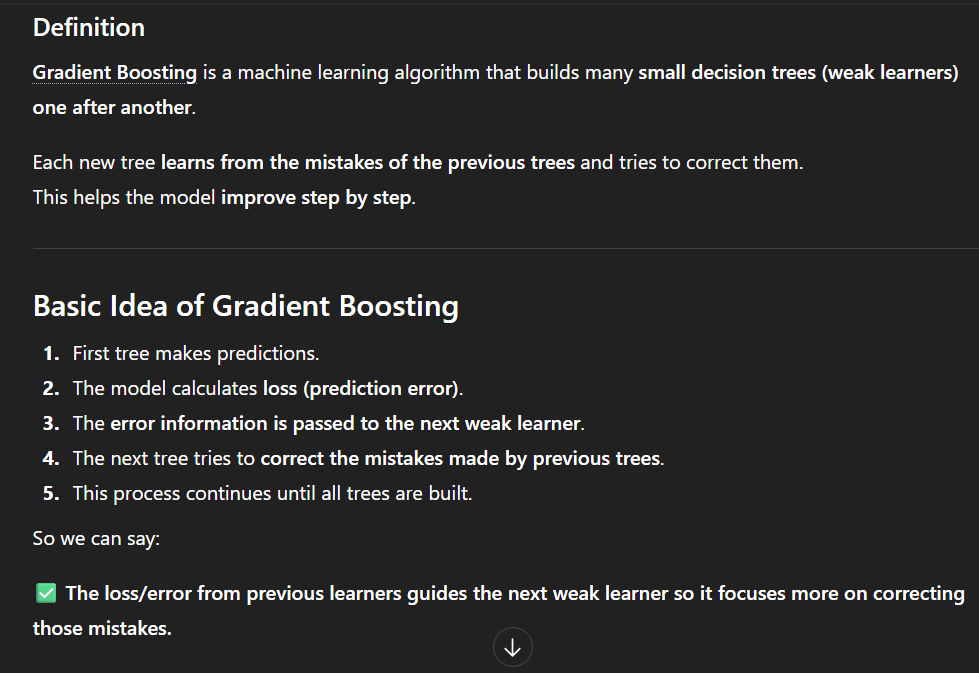

Most used Parameters of Gradient Boosting classifier-:
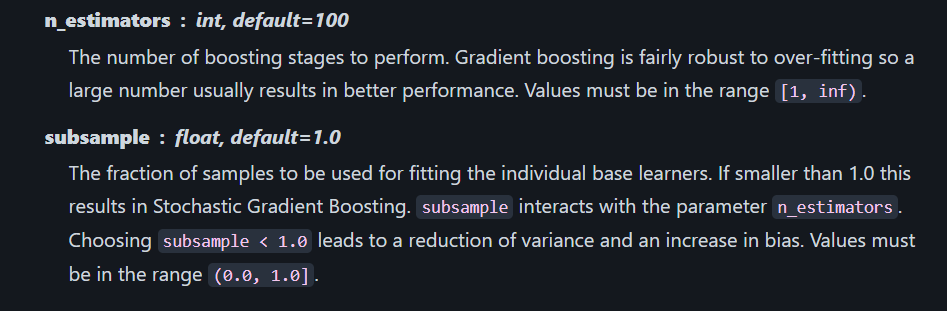
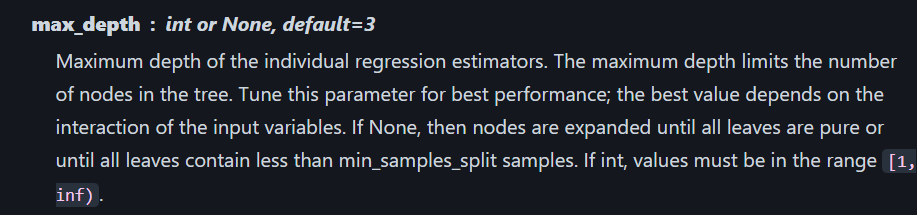
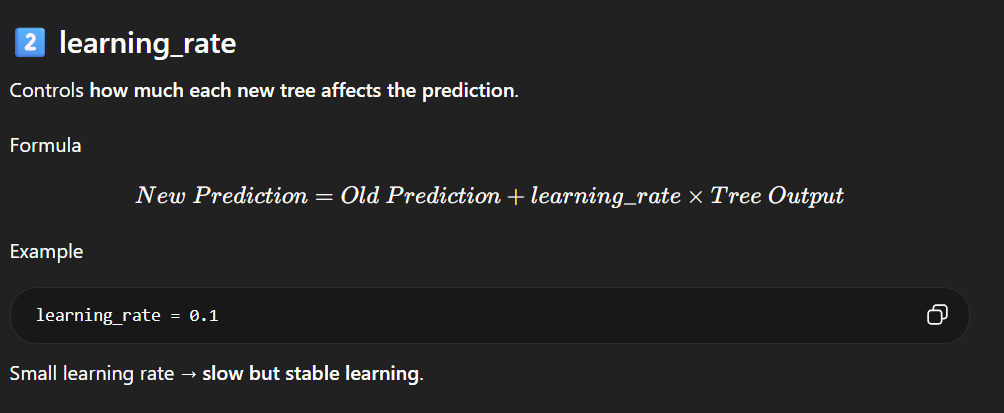
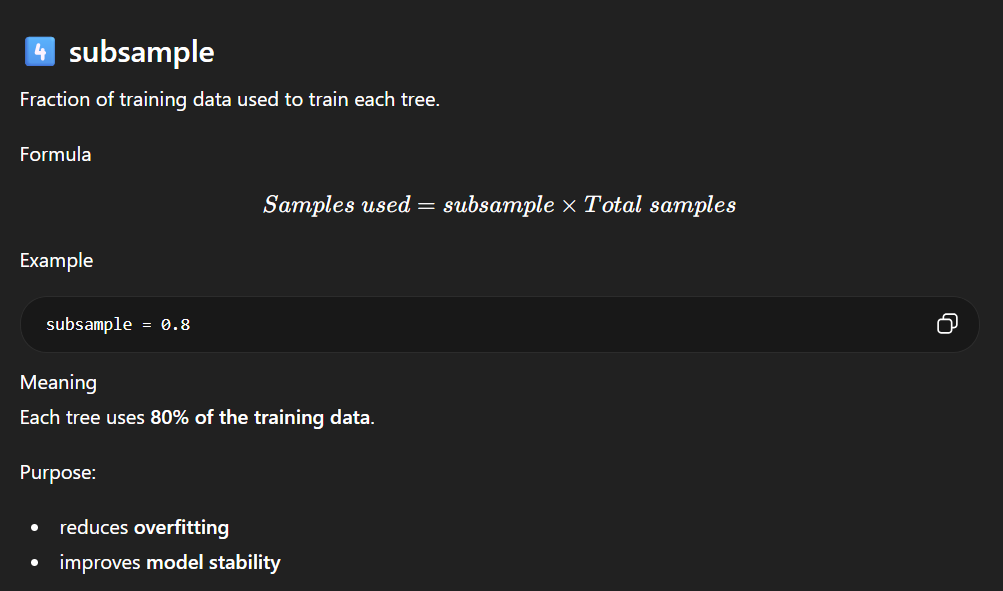
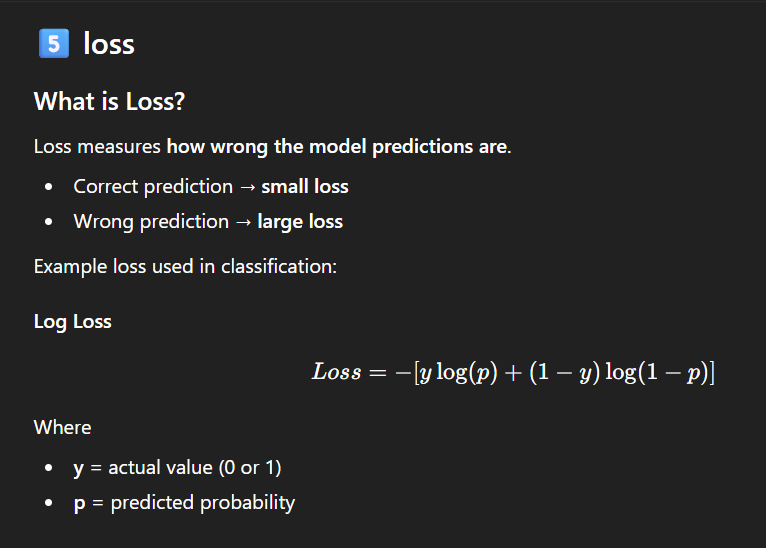

Log-loss is used for Binary Classification Problems
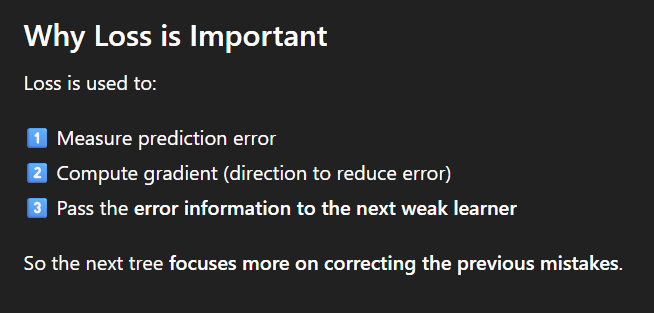
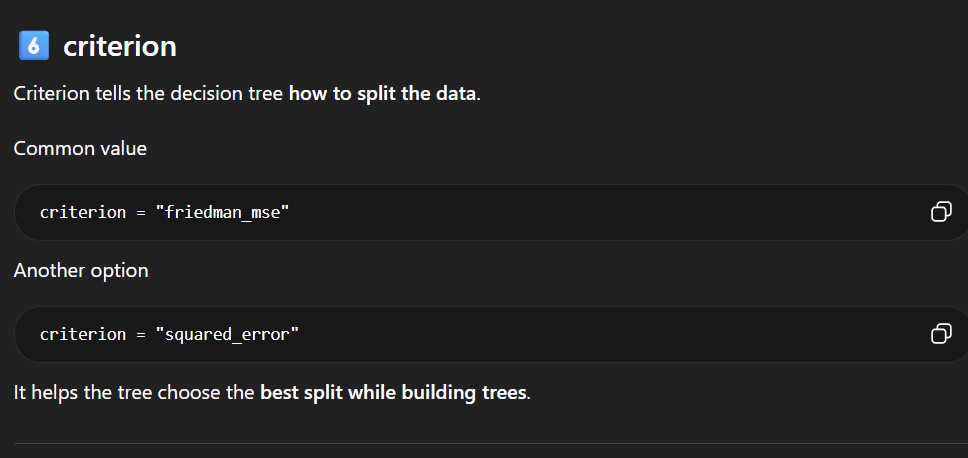
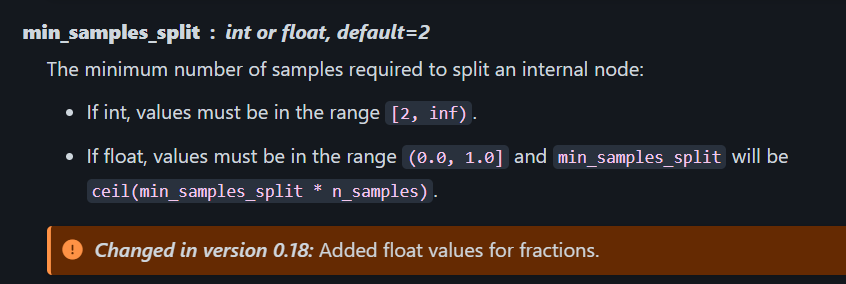
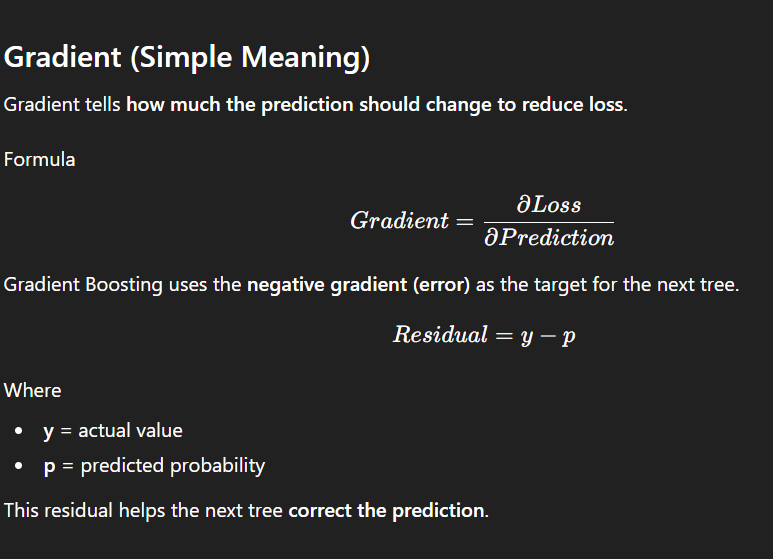
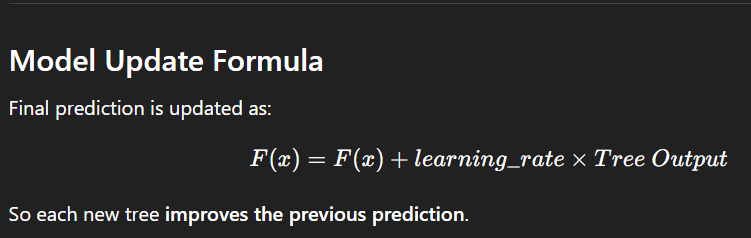



Gradient Boosting Classifier is an ensemble algorithm that builds multiple decision trees sequentially where each new tree learns from the loss or error of previous trees and improves prediction accuracy by reducing the overall error step by step.

In [ ]:
# HyperParameter Tunining of adboost_classifier-:
rf_params = {
            "max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]
             }

gradient_params = {
    "loss": ['log_loss', 'exponential'],
    'criterion':['friedmain_mse','squared_error'],
    "min_samples_split":[2,8,15,20],
    "n_estimators":[100,200,500,100],
    "max_depth":[5,8,15,None,10]
}

None in python == NULL in Java

In [85]:
type(np.nan)

float

In [84]:
np.nan

nan

In [83]:
np.isnan(np.nan)

np.True_

In [89]:
rf_params

{'max_depth': [5, 8, 15, None, 10],
 'max_features': [5, 7, 8],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200]}

In [90]:
gradient_params

{'loss': ['log_loss', 'exponential'],
 'criterion': ['friedmain_mse', 'squared_error'],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200],
 'max_depth': [5, 8, 15, None, 10]}

In [91]:
# Models list for HyperParameter Tuning-:
randomcv_models = [
    ("RF",RandomForestClassifier(),rf_params),
    ("Gradient Boost",GradientBoostingClassifier(),gradient_params)
]

In [92]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200]}),
 ('Gradient Boost',
  GradientBoostingClassifier(),
  {'loss': ['log_loss', 'exponential'],
   'criterion': ['friedmain_mse', 'squared_error'],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200],
   'max_depth': [5, 8, 15, None, 10]})]

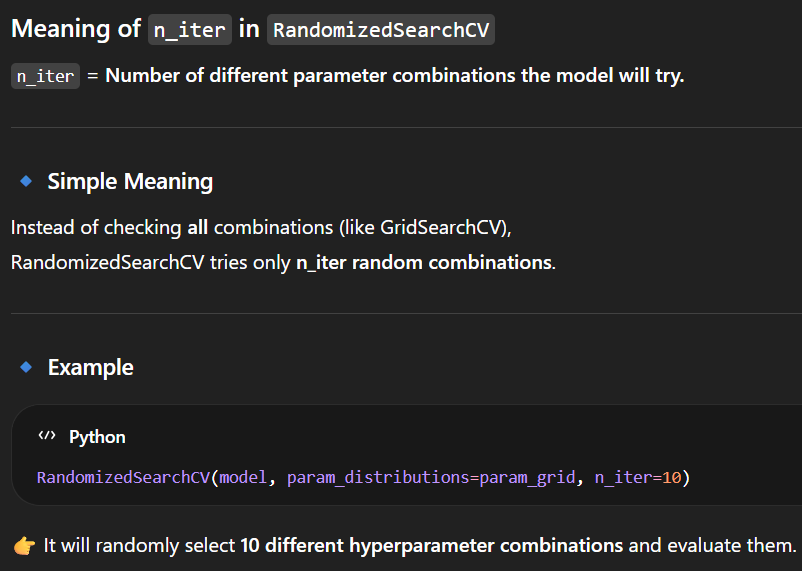
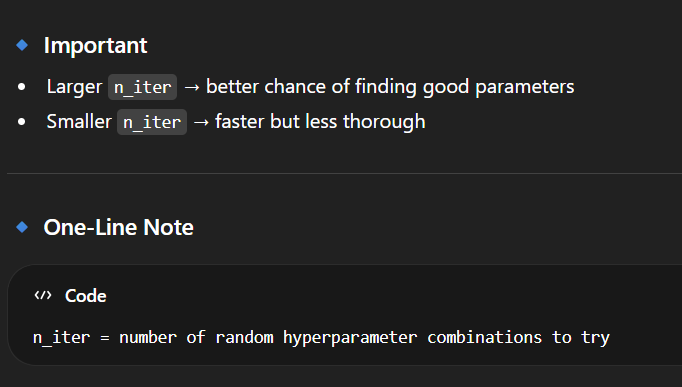

In [93]:
from sklearn.model_selection import RandomizedSearchCV
model_param = {}
models={}
for name,model,params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                                    param_distributions=params,n_iter=100,
                                                    cv=3,
                                                    verbose=2,
                                                    n_jobs=-1)
    
    random.fit(X_train,y_train)
    model_param[name] = random.best_params_
    models[name] = random.best_estimator_

for model_name in model_param:
    print(f"-------------------------Best Params for {model_name}-------------")
    print(model_param[model_name])


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits


c:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
135 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
135 fits failed with the following error:
Traceback (most recent call last):
  File "c:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
    ~~~~~~~~~

-------------------------Best Params for RF-------------
{'n_estimators': 200, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}
-------------------------Best Params for Gradient Boost-------------
{'n_estimators': 200, 'min_samples_split': 8, 'max_depth': 10, 'loss': 'exponential', 'criterion': 'squared_error'}


The warning means you used RandomizedSearchCV with n_iter=100, but few random combinations here that number is 135 cannot be applied together

For that reason training that model with those invalid combinaitons is not possible so RandomizedSearchCV set the values for these models as NaN/nan

In [94]:
model_param

{'RF': {'n_estimators': 200,
  'min_samples_split': 2,
  'max_features': 8,
  'max_depth': None},
 'Gradient Boost': {'n_estimators': 200,
  'min_samples_split': 8,
  'max_depth': 10,
  'loss': 'exponential',
  'criterion': 'squared_error'}}

In [95]:
random

RandomizedSearchCV(cv=3, estimator=GradientBoostingClassifier(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'criterion': ['friedmain_mse',
                                                      'squared_error'],
                                        'loss': ['log_loss', 'exponential'],
                                        'max_depth': [5, 8, 15, None, 10],
                                        'min_samples_split': [2, 8, 15, 20],
                                        'n_estimators': [100, 200]},
                   verbose=2)

In [96]:
random.best_estimator_

GradientBoostingClassifier(criterion='squared_error', loss='exponential',
                           max_depth=10, min_samples_split=8, n_estimators=200)

In [97]:
random.best_estimator_.n_estimators

200

In [98]:
models

{'RF': RandomForestClassifier(max_features=8, n_estimators=200),
 'Gradient Boost': GradientBoostingClassifier(criterion='squared_error', loss='exponential',
                            max_depth=10, min_samples_split=8, n_estimators=200)}

In [101]:
for i in range(len(list(models.keys()))):
    model = list(models.values())[i]

    # Make predicitons-:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate weighted F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- Weighted F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- Weighted F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')


RF
Model performance for Training set
- Accuracy: 1.0000
- Weighted F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9345
- Weighted F1 score: 0.9306
- Precision: 0.9333
- Recall: 0.6906
- Roc Auc Score: 0.8398


Gradient Boost
Model performance for Training set
- Accuracy: 1.0000
- Weighted F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9542
- Weighted F1 score: 0.9523
- Precision: 0.9613
- Recall: 0.7803
- Roc Auc Score: 0.8866




Here Gradient boosting has performed better than Random Forest Classifer

Also; due to HYPER-PARAMETER-TUNING -: Gradient boosting has performed very well than itself with DEFAULT PARAMETERS

# Efficient way of creating ROC-AUC curve

In [102]:
random.best_estimator_.predict_proba(X_test)

array([[8.36830093e-01, 1.63169907e-01],
       [1.00000000e+00, 1.41406729e-10],
       [9.99999947e-01, 5.25608553e-08],
       ...,
       [1.00000000e+00, 2.64704854e-10],
       [9.99999957e-01, 4.27520228e-08],
       [9.99999892e-01, 1.08152480e-07]])

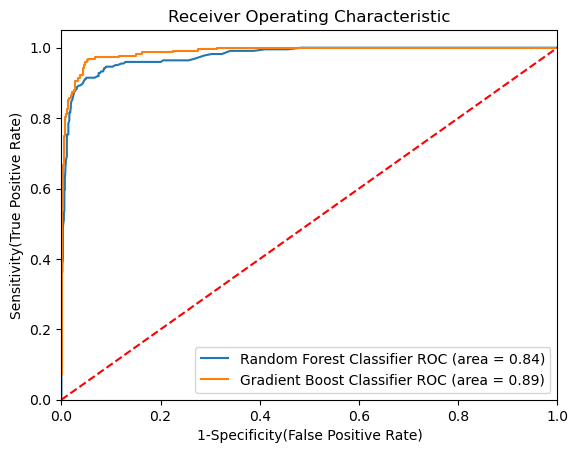

In [104]:
# Plot ROC AUC Curve
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Random Forest Classifier',
    'model': models['RF'],
    'auc':  0.8398
},
{
     'label': 'Gradient Boost Classifier',
    'model': models['Gradient Boost'],
    'auc':  0.8866
}
    
]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    # model.fit(X_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 

So; here clearly-: roc_curve of Gradient Boost classifer is better than of Random Forest classifer as roc_curve of Gradient Boost classifer covers 89% of toal area of curve [roc_auc_score=0.8866]

and roc_curve of Random Forest classifer covers 84% of toal area of curve [roc_auc_score=0.8398]

In [ ]:
print(f"{90000.0000033:.4f}")

90000.0000


In [ ]:
print("{:.4f}".format(90000.0000033))

90000.0000
